# **Preprocessing — Bukit Jaas LULC**

Tujuan: menyiapkan data siap latih berdasarkan insight dari `01_eda.ipynb`.
Output: feature matrix dan label vector siap untuk training di `experiments/`.

In [1]:
# CONFIG - File Path
labeled_data_path = "../data/labeled/labeled_data_manual_sampling.csv"
output_data_path  = "../data/processed/"

## **Load Data**

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [3]:
labeled_dataframe = pd.read_csv(labeled_data_path)
print(f"Shape: {labeled_dataframe.shape}")
labeled_dataframe.head()

Shape: (207, 17)


,longitude,latitude,B2,B3,B4,B8,B11,B12,NDVI,EVI,SAVI,NBR,ETH_CanopyHeight,Elevation,Slope,Aspect,Class
0,111.696567,-8.047602,1114.0,1284.0,1090.0,4232.0,2937.0,1854.0,0.590380,3.248553,0.885486,0.390733,30,265,35,208,Primary_Forest
1,111.696388,-8.047333,1238.0,1160.0,1082.0,3472.0,2557.0,1523.0,0.524813,8.786765,0.787134,0.390190,33,269,38,231,Primary_Forest
2,111.696747,-8.047243,938.0,940.0,848.0,2879.0,2689.0,1694.0,0.544942,5.442122,0.817304,0.259130,30,298,33,205,Primary_Forest
3,111.696747,-8.047423,906.0,862.0,849.0,2790.0,3030.0,1871.0,0.533388,4.451835,0.799973,0.197168,29,285,36,198,Primary_Forest
4,111.696927,-8.047692,965.0,1056.0,691.0,3696.0,2613.0,1484.0,0.684978,12.407102,1.027350,0.427027,26,264,31,186,Primary_Forest


In [4]:
# CONFIG - Preprocessing
SEED       = 42
test_size  = 0.2
use_smote  = False   # class_weight='balanced' dipilih — lihat 01_eda.ipynb

# Isi setelah melihat correlation matrix di 01_eda.ipynb
# Contoh: ["EVI", "SAVI"] jika berkorelasi tinggi dengan NDVI (|r| >= 0.85)
features_to_drop = []

all_feature_columns = [
    "B2", "B3", "B4", "B8", "B11", "B12",
    "NDVI", "EVI", "SAVI", "NBR",
    "ETH_CanopyHeight",
    "Elevation", "Slope", "Aspect"
]
target_column = "Class"
id_columns    = ["longitude", "latitude"]

---
# **Feature Selection**

In [5]:
active_feature_columns = [f for f in all_feature_columns if f not in features_to_drop]

print(f"Total features  : {len(all_feature_columns)}")
print(f"Features dropped: {features_to_drop if features_to_drop else 'None'}")
print(f"Features used   : {len(active_feature_columns)}")
print(active_feature_columns)

Total features  : 14
Features dropped: None
Features used   : 14
['B2', 'B3', 'B4', 'B8', 'B11', 'B12', 'NDVI', 'EVI', 'SAVI', 'NBR', 'ETH_CanopyHeight', 'Elevation', 'Slope', 'Aspect']


---
# **Handle Class Imbalance**

**Keputusan: `class_weight='balanced'` di model RF.**

Alasan:
- Dataset kecil (207 sampel). SMOTE dengan kelas Settlement=9 sampel berisiko
  menghasilkan synthetic sample yang terlalu mirip (k-neighbors terlalu sedikit).
- `class_weight='balanced'` cukup efektif untuk RF dan tidak memerlukan library tambahan.
- Referensi: [scikit-learn docs — class_weight](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

In [6]:
class_distribution = labeled_dataframe[target_column].value_counts()
imbalance_ratio    = class_distribution.max() / class_distribution.min()

print("Class distribution:")
print(class_distribution.to_string())
print(f"\nImbalance ratio (max/min): {imbalance_ratio:.1f}x")
print(f"Strategy applied         : class_weight='balanced' in RandomForestClassifier")

Class distribution:
Class
Secondary_Forest    70
Primary_Forest      50
Estate_Crop         40
Bare_Ground         23
Paddy_Field         15
Settlement           9

Imbalance ratio (max/min): 7.8x
Strategy applied         : class_weight='balanced' in RandomForestClassifier


---
# **Split Data**

Stratified split memastikan proporsi kelas terjaga di train dan test set.

In [7]:
feature_matrix   = labeled_dataframe[active_feature_columns]
target_labels    = labeled_dataframe[target_column]
identifier_frame = labeled_dataframe[id_columns]

print(f"Feature matrix shape : {feature_matrix.shape}")
print(f"Target labels shape  : {target_labels.shape}")

Feature matrix shape : (207, 14)
Target labels shape  : (207,)


In [8]:
(
    train_feature_matrix, test_feature_matrix,
    train_labels, test_labels,
    train_identifiers, test_identifiers
) = train_test_split(
    feature_matrix, target_labels, identifier_frame,
    test_size=test_size,
    random_state=SEED,
    stratify=target_labels
)

print(f"Train size : {len(train_feature_matrix)} samples ({len(train_feature_matrix)/len(feature_matrix)*100:.0f}%)")
print(f"Test size  : {len(test_feature_matrix)} samples ({len(test_feature_matrix)/len(feature_matrix)*100:.0f}%)")

Train size : 165 samples (80%)
Test size  : 42 samples (20%)


In [9]:
split_comparison = pd.DataFrame({
    "full" : target_labels.value_counts(normalize=True).mul(100).round(1),
    "train": train_labels.value_counts(normalize=True).mul(100).round(1),
    "test" : test_labels.value_counts(normalize=True).mul(100).round(1),
}).fillna(0)
split_comparison.columns = ["full (%)", "train (%)", "test (%)"]

print("Class proportion before and after split:")
print(split_comparison.to_string())

Class proportion before and after split:
                  full (%)  train (%)  test (%)
Class                                          
Secondary_Forest      33.8       33.9      33.3
Primary_Forest        24.2       24.2      23.8
Estate_Crop           19.3       19.4      19.0
Bare_Ground           11.1       10.9      11.9
Paddy_Field            7.2        7.3       7.1
Settlement             4.3        4.2       4.8


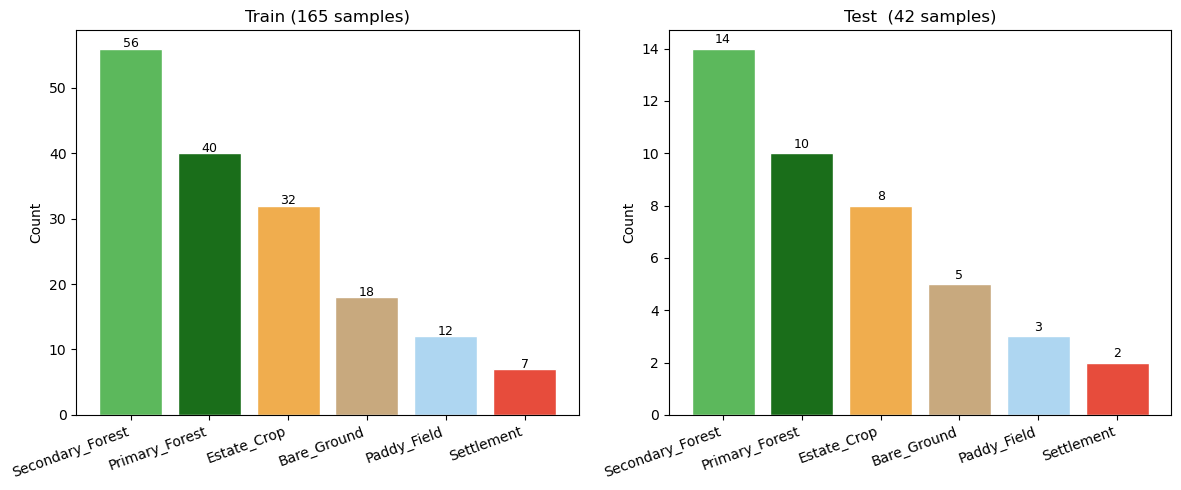

In [10]:
lulc_class_colors = {
    "Primary_Forest"   : "#1a6e1a",
    "Secondary_Forest" : "#5cb85c",
    "Estate_Crop"      : "#f0ad4e",
    "Paddy_Field"      : "#aed6f1",
    "Settlement"       : "#e74c3c",
    "Bare_Ground"      : "#c8a97e",
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

for ax, (label_series, title) in zip(axes, [
    (train_labels, f"Train ({len(train_labels)} samples)"),
    (test_labels,  f"Test  ({len(test_labels)} samples)"),
]):
    counts = label_series.value_counts()
    bar_colors = [lulc_class_colors.get(cls, "#999") for cls in counts.index]
    ax.bar(counts.index, counts.values, color=bar_colors, edgecolor="white")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.2, str(v), ha="center", fontsize=9)
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

plt.tight_layout()
plt.show()

---
# **Save Processed Data** *(opsional)*

Simpan jika ingin load langsung di notebook experiment tanpa re-run preprocessing.

In [11]:
save_processed = False   # set True untuk menyimpan

if save_processed:
    os.makedirs(output_data_path, exist_ok=True)

    train_dataframe = train_feature_matrix.copy()
    train_dataframe[target_column] = train_labels.values
    train_dataframe.to_csv(output_data_path + "train_split.csv", index=False)

    test_dataframe = test_feature_matrix.copy()
    test_dataframe[target_column] = test_labels.values
    test_dataframe.to_csv(output_data_path + "test_split.csv", index=False)

    print(f"Saved train to: {output_data_path}train_split.csv")
    print(f"Saved test  to: {output_data_path}test_split.csv")
else:
    print("save_processed = False. Data tidak disimpan ke disk.")

save_processed = False. Data tidak disimpan ke disk.
